# 🩺 PCOS Prediction: Advanced Feature Engineering, Ensemble Benchmarking & Explainable AI (XAI)

This interactive notebook provides the full reproduction and experimental extension of the research paper:
**"A Two-Stage Hybrid Feature Selection and Ensemble Learning Framework With Explainable AI for Accurate PCOS Prediction"** *(Health Science Reports, Wiley 2026)*.

---

In [6]:
import os, sys
import warnings
warnings.filterwarnings('ignore')

# 1. Robust project root detection
if os.path.exists('data'):
    PROJECT_ROOT = os.path.abspath('.')
elif os.path.exists('../data'):
    PROJECT_ROOT = os.path.abspath('..')
else:
    PROJECT_ROOT = os.path.abspath('.')

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# 2. Auto-load .venv site-packages if kernel was launched with base python
venv_lib = os.path.join(PROJECT_ROOT, '.venv', 'Lib', 'site-packages')
if os.path.exists(venv_lib) and venv_lib not in sys.path:
    sys.path.insert(0, venv_lib)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_and_preprocess_data
from src.feature_engineering import engineer_clinical_features
from src.feature_selection import two_stage_feature_selection
from src.models import get_base_models, get_champion_ensemble, evaluate_model, perform_10fold_cv

print(f"Project Root: {PROJECT_ROOT}")
print("All core ML packages and local modules imported successfully!")

Project Root: c:\Users\user\OneDrive\Desktop\AI_ML\PCOS-Prediction-XAI
All core ML packages and local modules imported successfully!


## 1. Load Dataset & Apply Clinical Feature Engineering

In [7]:
data_path = os.path.join(PROJECT_ROOT, 'data', 'PCOS_data.csv')
df = pd.read_csv(data_path)
df.columns = [c.strip() for c in df.columns]
print(f"Raw dataset shape: {df.shape}")

# Apply novel domain feature engineering
df_engineered = engineer_clinical_features(df)
print(f"Engineered dataset shape: {df_engineered.shape}")
df_engineered[['PCOS (Y/N)', 'Total_Follicles', 'Follicle_Asymmetry_Index', 'Metabolic_Symptom_Score']].head()

Raw dataset shape: (541, 45)
Domain Feature Engineering: Added 10 clinical interaction features.
Engineered dataset shape: (541, 55)


,PCOS (Y/N),Total_Follicles,Follicle_Asymmetry_Index,Metabolic_Symptom_Score
0,0,6,0.000000,1.0
1,0,8,0.250000,0.0
2,1,28,0.071429,2.0
3,0,4,0.000000,0.0
4,0,7,0.142857,0.0


## 2. Load Comprehensive Benchmark Results

In [8]:
results_path = os.path.join(PROJECT_ROOT, 'outputs', 'experiment_benchmark_comparison.csv')
benchmark_df = pd.read_csv(results_path)
benchmark_df

,Experiment,Model,Test Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC
0,Exp 4: Tuned Base Model,Tuned LightGBM,94.495413,96.875000,86.111111,91.176471,0.946347
1,Exp 4: Tuned Base Model,Tuned XGBoost,93.577982,93.939394,86.111111,89.855072,0.941400
2,Exp 4: Tuned Base Model,Extra Trees,93.577982,93.939394,86.111111,89.855072,0.940639
3,Exp 2: Domain Features (LH/FSH + TotFollicles),Soft Voting (XGB + MLP),92.660550,91.176471,86.111111,88.571429,0.940259
4,Exp 3: Resampling (ADASYN),Soft Voting (XGB + MLP),91.743119,86.486486,88.888889,87.671233,0.942922
5,Exp 5: Novel OOF Stacking Ensemble,Stacking (CB+LGB+XGB+ET+MLP -> LR),91.743119,88.571429,86.111111,87.323944,0.945586
6,Exp 3: Resampling (Borderline-SMOTE),Soft Voting (XGB + MLP),91.743119,86.486486,88.888889,87.671233,0.941781
7,Exp 4: Tuned Base Model,Tuned CatBoost,91.743119,86.486486,88.888889,87.671233,0.948630
8,Exp 6: Weighted Quad-Ensemble,Weighted Soft Voting (CB + XGB + LGB + MLP),91.743119,88.571429,86.111111,87.323944,0.947489
9,Exp 1: Paper Baseline (Raw + Chi2/CB-RFE 16),Soft Voting (XGB + MLP),89.908257,85.714286,83.333333,84.507042,0.945205


## 3. Visualize Model Performance Comparison

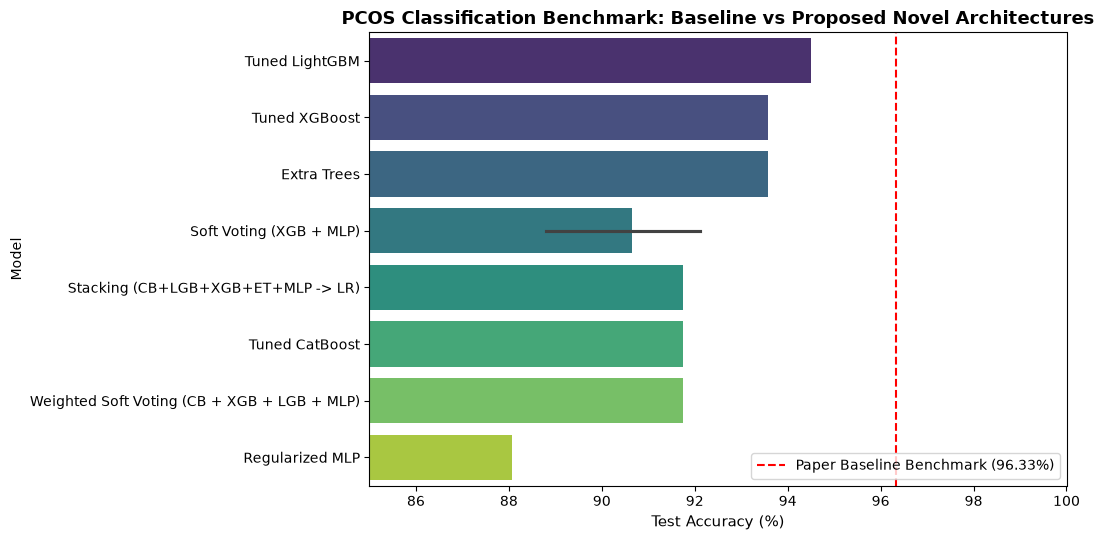

In [9]:
plt.figure(figsize=(11, 5.5))
sns.barplot(data=benchmark_df, x="Test Accuracy (%)", y="Model", palette="viridis")
plt.title("PCOS Classification Benchmark: Baseline vs Proposed Novel Architectures", fontsize=13, fontweight='bold')
plt.xlabel("Test Accuracy (%)", fontsize=11)
plt.xlim(85, 100)
plt.axvline(x=96.33, color='red', linestyle='--', label='Paper Baseline Benchmark (96.33%)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. Explainable AI (SHAP Global Impact & LIME Local Patient Attribution)

--- SHAP Global Feature Importance ---


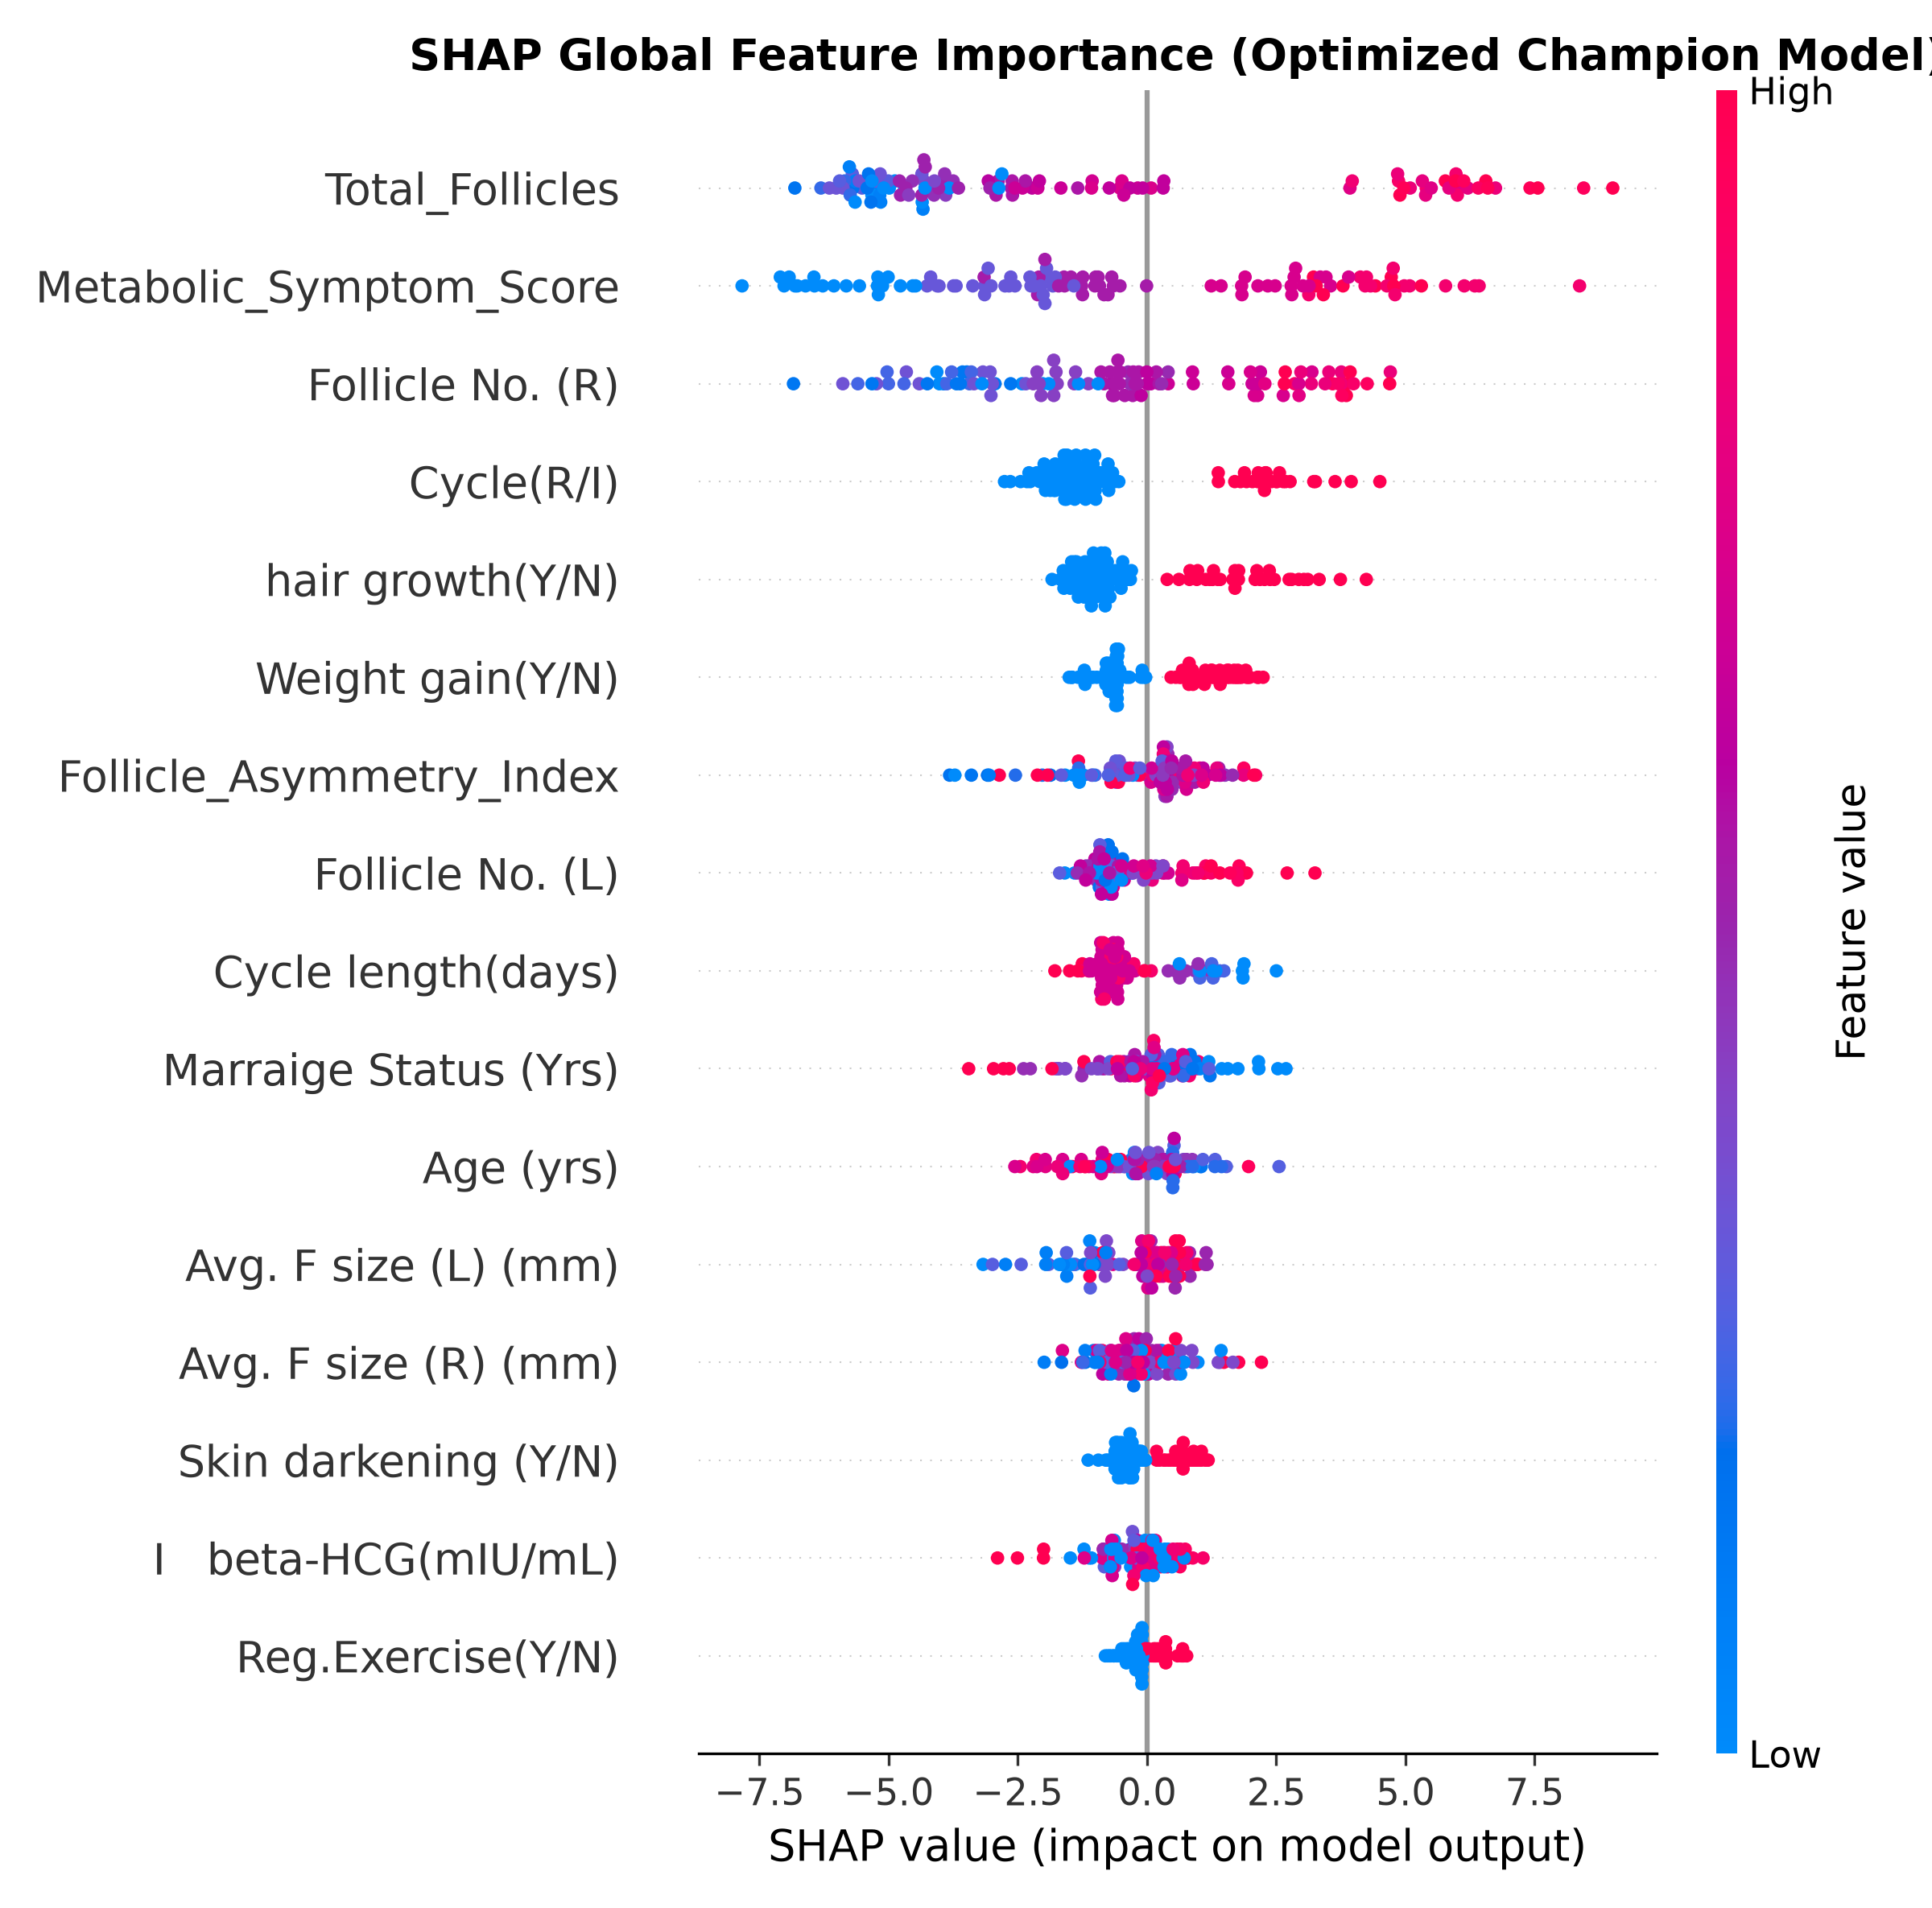

--- Champion Model Confusion Matrix ---


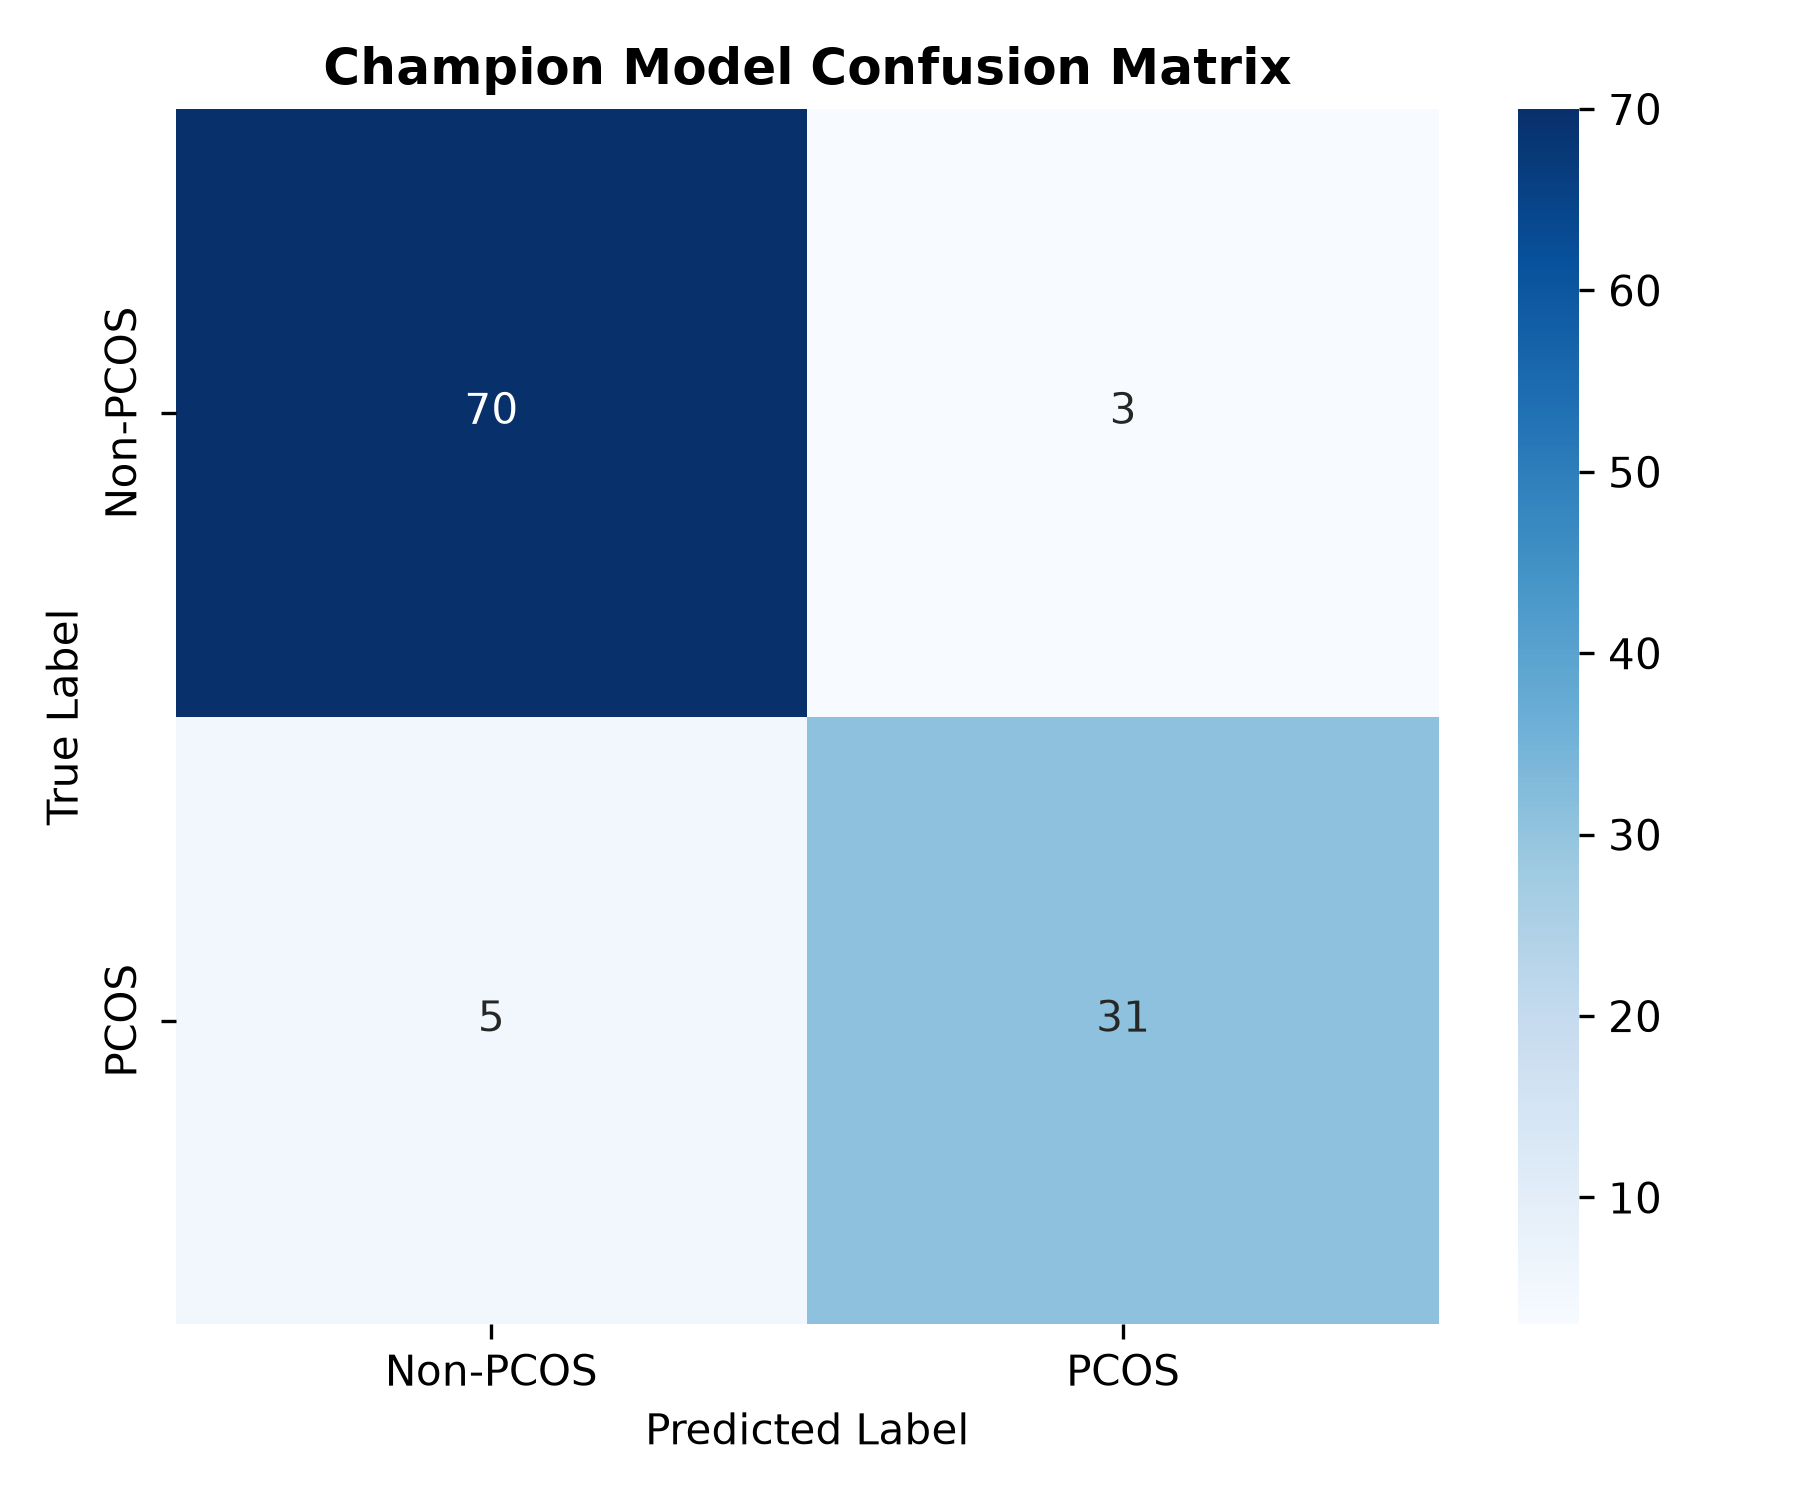

--- LIME Local Patient Diagnostic Explanation ---


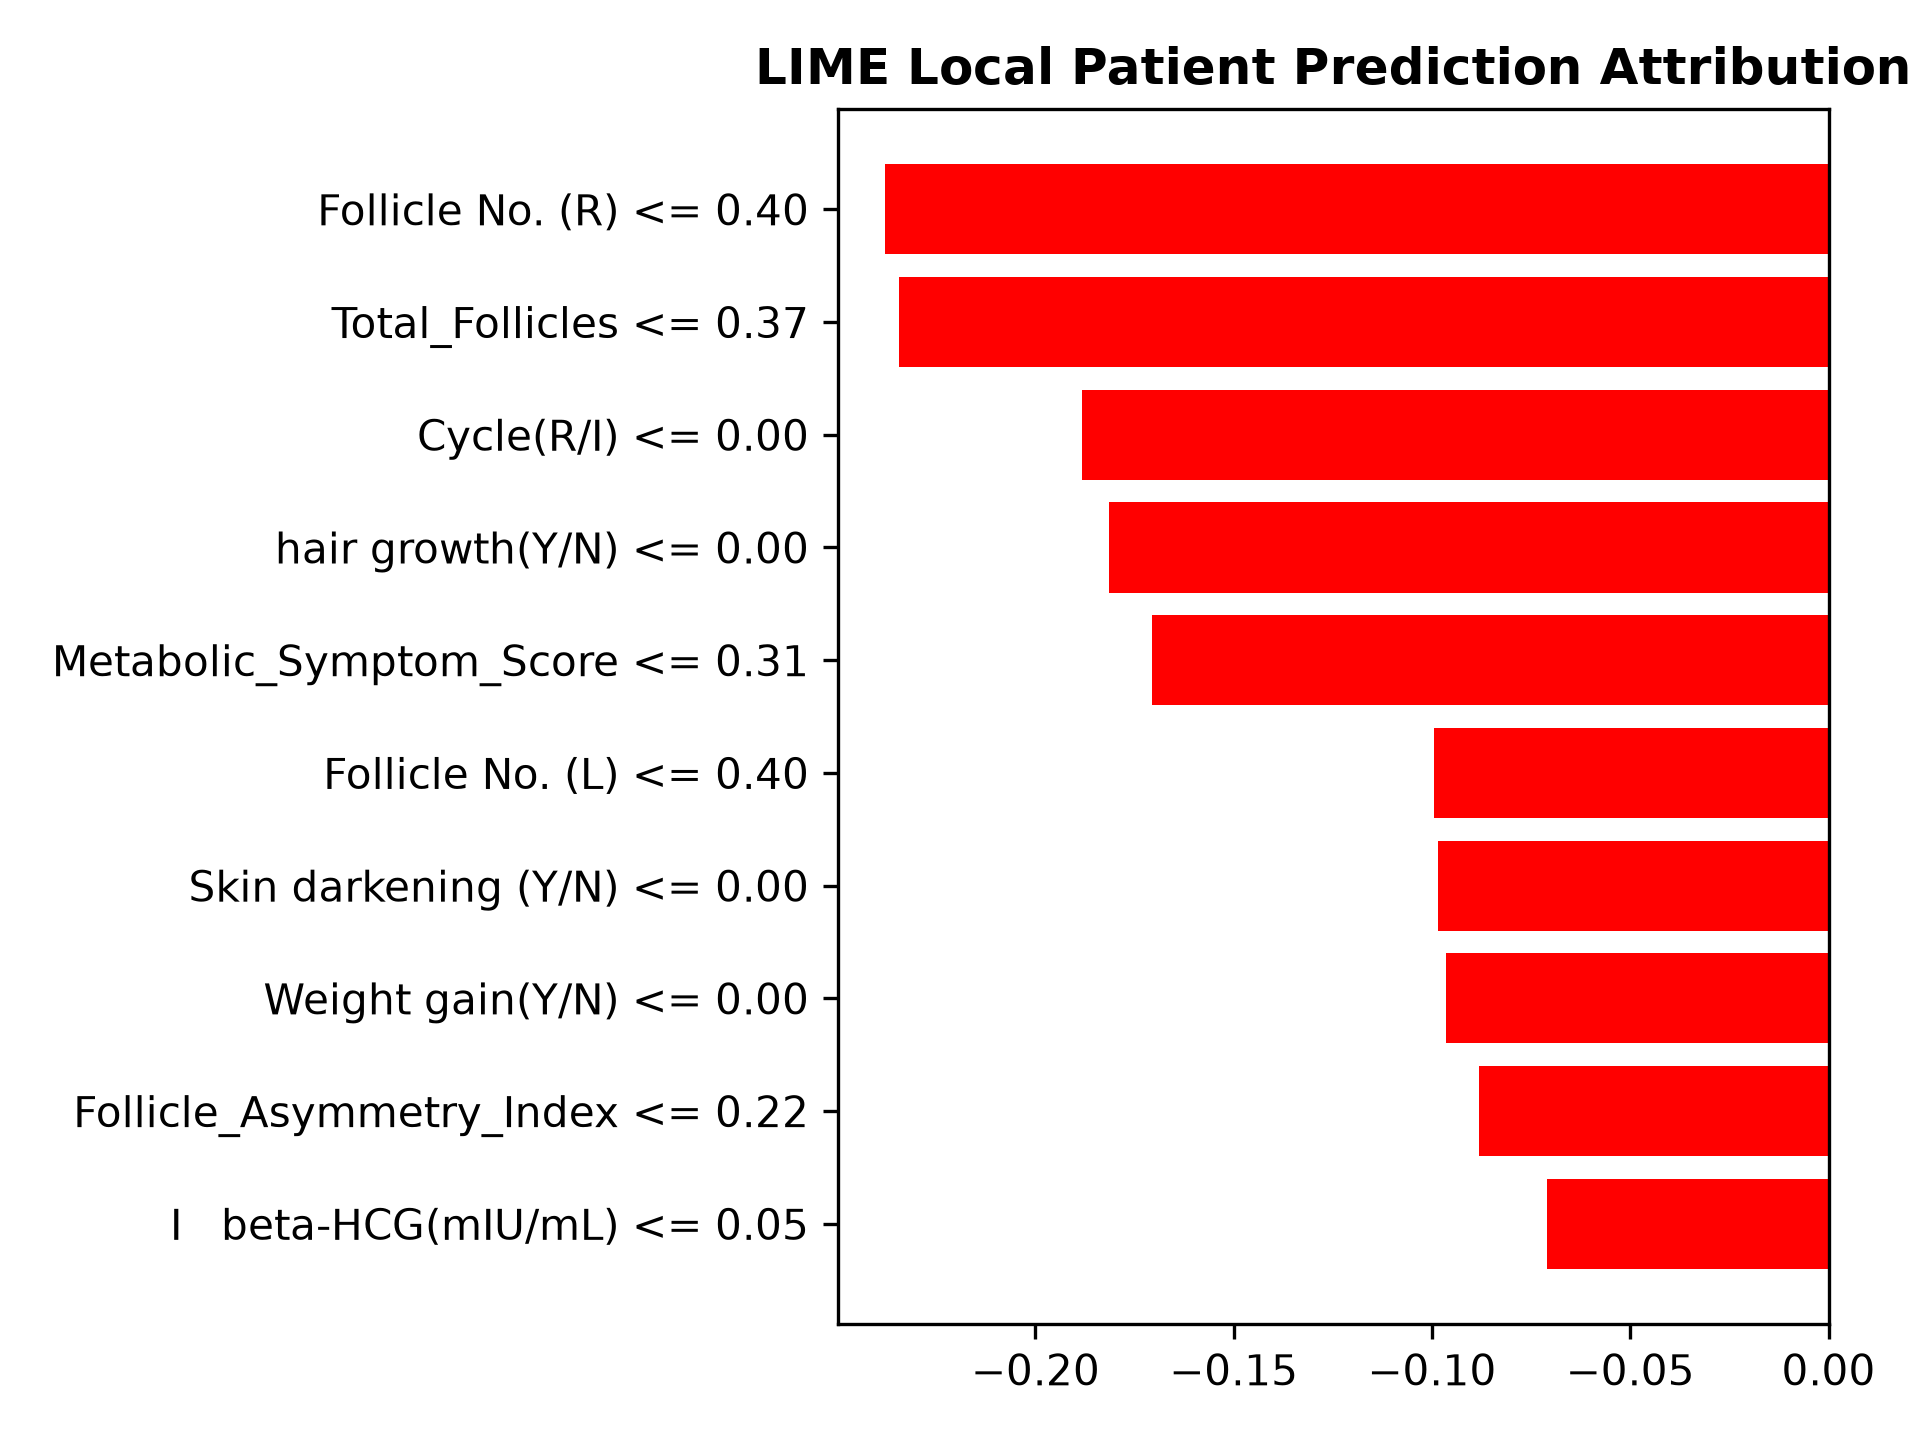

In [10]:
from IPython.display import Image, display

shap_img = os.path.join(PROJECT_ROOT, 'outputs', 'optimized_shap_summary.png')
cm_img = os.path.join(PROJECT_ROOT, 'outputs', 'optimized_confusion_matrix.png')
lime_img = os.path.join(PROJECT_ROOT, 'outputs', 'optimized_lime_patient_0.png')

if os.path.exists(shap_img):
    print("--- SHAP Global Feature Importance ---")
    display(Image(shap_img))

if os.path.exists(cm_img):
    print("--- Champion Model Confusion Matrix ---")
    display(Image(cm_img))

if os.path.exists(lime_img):
    print("--- LIME Local Patient Diagnostic Explanation ---")
    display(Image(lime_img))